# Fragrantica 香水相似推荐系统

这个 Notebook 的目标是构建一个简单、可解释的香水推荐系统。

核心问题是：

如果用户喜欢一款香水，我们能不能根据它的香调、前调、中调、后调，推荐气味结构相似的香水？

本项目使用的是基于内容的推荐系统，也就是根据“香水本身的内容特征”来推荐。

## 1. 导入工具包和读取数据

这里要注意：原始 CSV 文件使用分号分隔，并且编码是 cp1252，所以读取时要指定 `sep` 和 `encoding`。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

data_path = "fra_cleaned.csv"

df = pd.read_csv(data_path, sep=";", encoding="cp1252", decimal=",")
df.head()


,url,Perfume,Brand,Country,Gender,Rating Value,Rating Count,Year,Top,Middle,Base,Perfumer1,Perfumer2,mainaccord1,mainaccord2,mainaccord3,mainaccord4,mainaccord5
0,https://www.fragrantica.com/perfume/xerjoff/ac...,accento-overdose-pride-edition,xerjoff,Italy,unisex,1.42,201,2022.0,"fruity notes, aldehydes, green notes","bulgarian rose, egyptian jasmine, lily-of-the-...","eucalyptus, pine",unknown,NaN,rose,woody,fruity,aromatic,floral
1,https://www.fragrantica.com/perfume/jean-paul-...,classique-pride-2024,jean-paul-gaultier,France,women,1.86,70,2024.0,"yuzu, citruses","orange blossom, neroli","musk, blonde woods",unknown,NaN,citrus,white floral,sweet,fresh,musky
2,https://www.fragrantica.com/perfume/jean-paul-...,classique-pride-2023,jean-paul-gaultier,France,unisex,1.91,285,2023.0,"blood orange, yuzu","neroli, orange blossom","musk, white woods",natalie gracia-cetto,quentin bisch,citrus,white floral,sweet,fresh spicy,musky
3,https://www.fragrantica.com/perfume/bruno-bana...,pride-edition-man,bruno-banani,Germany,men,1.92,59,2019.0,"guarana, grapefruit, red apple","walnut, lavender, guava","vetiver, benzoin, amber",unknown,NaN,fruity,nutty,woody,tropical,NaN
4,https://www.fragrantica.com/perfume/jean-paul-...,le-male-pride-collector,jean-paul-gaultier,France,men,1.93,632,2020.0,"mint, lavender, cardamom, artemisia, bergamot","caraway, cinnamon, orange blossom","vanilla, sandalwood, amber, cedar, tonka bean",francis kurkdjian,NaN,aromatic,warm spicy,fresh spicy,cinnamon,vanilla


## 2. 基础清洗

推荐系统要用香调、前调、中调、后调这些文本字段，所以先统一处理空格、空值和数值字段。

In [2]:
df.columns = [c.strip() for c in df.columns]

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace({"": np.nan, "nan": np.nan, "unknown": np.nan, "Unknown": np.nan})

df["Rating Value"] = pd.to_numeric(df["Rating Value"], errors="coerce")
df["Rating Count"] = pd.to_numeric(df["Rating Count"], errors="coerce")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

df["Popularity Score"] = df["Rating Value"] * np.log1p(df["Rating Count"])

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24063 entries, 0 to 24062
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   url               24063 non-null  object 
 1   Perfume           24063 non-null  object 
 2   Brand             24063 non-null  object 
 3   Country           24063 non-null  object 
 4   Gender            24063 non-null  object 
 5   Rating Value      24063 non-null  float64
 6   Rating Count      24063 non-null  int64  
 7   Year              22026 non-null  float64
 8   Top               24063 non-null  object 
 9   Middle            24063 non-null  object 
 10  Base              24063 non-null  object 
 11  Perfumer1         11743 non-null  object 
 12  Perfumer2         1336 non-null   object 
 13  mainaccord1       24063 non-null  object 
 14  mainaccord2       24050 non-null  object 
 15  mainaccord3       23949 non-null  object 
 16  mainaccord4       23675 non-null  object

## 3. 构造香水气味文本 feature_text

推荐系统需要知道“每款香水像什么”。这里我们把主香调、前调、中调、后调合并成一段文本。

比如一款香水的特征可能变成：

`vanilla sweet warm spicy coffee white floral pear orange blossom patchouli cedar`

这段文本就相当于这款香水的“气味身份证”。

In [3]:
accord_cols = [c for c in df.columns if c.startswith("mainaccord")]
note_cols = [c for c in ["Top", "Middle", "Base"] if c in df.columns]
text_cols = accord_cols + note_cols

def clean_text_value(x):
    if pd.isna(x):
        return ""
    return str(x).lower().replace(",", " ").replace(";", " ").replace("|", " ")

df["feature_text"] = ""
for col in text_cols:
    df["feature_text"] += " " + df[col].apply(clean_text_value)

df["feature_text"] = df["feature_text"].str.replace(r"\s+", " ", regex=True).str.strip()

rec_df = df[df["feature_text"].str.len() > 0].copy().reset_index(drop=True)

rec_df[["Perfume", "Brand", "feature_text"]].head()


,Perfume,Brand,feature_text
0,accento-overdose-pride-edition,xerjoff,rose woody fruity aromatic floral fruity notes...
1,classique-pride-2024,jean-paul-gaultier,citrus white floral sweet fresh musky yuzu cit...
2,classique-pride-2023,jean-paul-gaultier,citrus white floral sweet fresh spicy musky bl...
3,pride-edition-man,bruno-banani,fruity nutty woody tropical guarana grapefruit...
4,le-male-pride-collector,jean-paul-gaultier,aromatic warm spicy fresh spicy cinnamon vanil...


## 4. 用 TF-IDF 把文本转成数字

电脑不能直接理解 “vanilla”“woody”“floral” 这些词，所以要把文本转成数字向量。

这里用 TF-IDF。你可以简单理解为：

- 一个词在这款香水里出现，说明它有用；
- 但如果这个词在所有香水里都很常见，它的区分度就会降低；
- 如果这个词能代表某些香水的独特气味，它的权重就会更高。

这样每款香水都会变成一个数字向量。

In [4]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=3000,
    ngram_range=(1, 2)
)

tfidf_matrix = vectorizer.fit_transform(rec_df["feature_text"])

tfidf_matrix.shape


(24063, 3000)

## 5. 用余弦相似度计算香水相似程度

TF-IDF 得到数字向量之后，就可以计算两款香水的相似度。

这里用余弦相似度。你可以简单理解为：

两款香水的气味向量方向越接近，相似度越高。

相似度越接近 1，说明越相似；越接近 0，说明越不相似。

In [5]:
def search_perfume(keyword, top_n=10):
    mask = (
        rec_df["Perfume"].str.contains(keyword, case=False, na=False)
        | rec_df["Brand"].str.contains(keyword, case=False, na=False)
    )
    return rec_df.loc[
        mask,
        ["Perfume", "Brand", "Country", "Gender", "Rating Value", "Rating Count", "Year"]
    ].head(top_n)

search_perfume("Black Opium")


,Perfume,Brand,Country,Gender,Rating Value,Rating Count,Year


In [6]:
def recommend_by_index(idx, top_n=10, min_rating_count=50):
    # 计算目标香水和所有香水的相似度
    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()

    result = rec_df.copy()
    result["Similarity"] = sim_scores

    # 去掉它自己
    result = result[result.index != idx]

    # 过滤评分人数太少的香水，避免推荐太冷门、可信度不足的样本
    result = result[result["Rating Count"].fillna(0) >= min_rating_count]

    # 先按相似度排序，相似度一样时再参考综合热度
    result = result.sort_values(["Similarity", "Popularity Score"], ascending=False)

    return result[
        ["Perfume", "Brand", "Country", "Gender", "Rating Value", "Rating Count",
         "Popularity Score", "Similarity", "Year"]
    ].head(top_n).round(3)


def recommend_perfume(keyword, top_n=10, min_rating_count=50):
    matches = search_perfume(keyword, top_n=5)

    if matches.empty:
        print(f"No perfume found for keyword: {keyword}")
        return None

    idx = matches.index[0]
    print("Target perfume:")
    display(rec_df.loc[[idx], ["Perfume", "Brand", "Country", "Gender", "Rating Value", "Rating Count", "Year"]])

    print("\nRecommended perfumes:")
    return recommend_by_index(idx, top_n=top_n, min_rating_count=min_rating_count)


## 6. 试运行推荐系统

你可以把下面的关键词换成你想查的香水名或品牌名。

In [7]:
recommend_perfume("Black Opium", top_n=10, min_rating_count=50)


No perfume found for keyword: Black Opium


## 7. 看一下相似度分布

这张图不是必须放进报告，但可以帮助你理解：对于某一款香水，大部分其他香水其实相似度都很低，只有少数香水真的接近它。

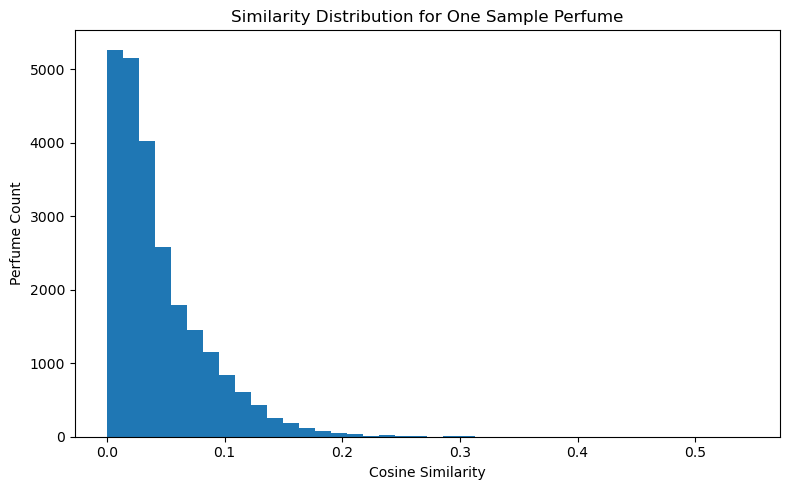

In [8]:
matches = search_perfume("Black Opium", top_n=5)

if not matches.empty:
    idx = matches.index[0]
else:
    idx = 0

scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
scores = np.delete(scores, idx)

plt.figure(figsize=(8, 5))
plt.hist(scores, bins=40)
plt.xlabel("Cosine Similarity")
plt.ylabel("Perfume Count")
plt.title("Similarity Distribution for One Sample Perfume")
plt.tight_layout()
plt.show()


## 8. 这一步怎么写进报告

本项目基于香水的 main accords、Top、Middle 和 Base notes 构建气味文本特征，使用 TF-IDF 将文本转化为数值向量，并通过余弦相似度计算香水之间的相似程度。最终实现输入一款目标香水，返回气味结构最相似的 10 款香水。

这个推荐系统属于基于内容的推荐方法，优点是可解释性较强，不需要用户历史行为数据；局限是只能根据香水已有特征推荐相似产品，不能直接判断用户个人是否一定喜欢。